# Symbolic XOR Criterion (SXC)

## What this is

Not a benchmark, not a ranking. A minimal visible form of prior-free
underdetermination, not a representation-capacity claim. (Minsky–Papert's
XOR is about what a model class can express; here the model is given, and
the question is what pointwise data can determine.)

## The impossibility

**Identification (section 7).** Any method whose access to the target is
black-box single-point queries, with no prior (no function class, no
regularity) and no other escape, cannot guarantee recovery of the a.e.
decision rule for every target: a finite or countable query set has
measure zero, and section 7 constructs, against any such protocol, a
target that matches every observed value and decides differently on a
positive-measure set. The escapes: a prior, either parameterized (a
finite-dimensional class plus enough points in general position) or
regularized (smoothness plus dense coverage), or almost-everywhere
(co-null) coverage. (Two further items sometimes listed, no global
symbolic search and per-sample outputs, are not premises of this; they
describe the methods under test and the format the verdicts read.)

**Format (sections 3–4).** The methods under test emit per-sample objects.
A per-sample object can be pointwise exact (at b = 0 the pair term
carries the entire logit) and still not be a rule object. That is what
the verdicts read.

## Verdicts

- **L2:** the output's sign agrees with the rule sign at every probe point.
  Only probe values are available, so nothing is claimed about whether the
  output is a constant object.
- **L3:** the output carries a per-point interaction component w_{1,2}(x)
  whose sign opposes the rule sign at some probe point. (The strongest case:
  the component is pointwise exact.)
- **L4:** the output has no component indexed by the pair {1,2}. A fact
  about the output's format, independent of any probe.

L1 (the rule object itself) is the target of the experiment, not a verdict.
Reaching it requires external information: a prior on the function class
(in algorithmic form, a global symbolic search), or almost-everywhere
coverage. See sections 7–8.

Any per-sample quantity is a per-point value. It is not a rule.

## How the values are computed

Every interaction value below is produced by a third-party implementation,
not by code written here:

- Harsanyi dividend / Moebius transform and SHAP-IQ (SII): `shapiq`,
  `ExactComputer`, which enumerates all 2^n coalitions.
- AOG (And-Or graph, CVPR 2023): the official implementation,
  `github.com/sjtu-xai-lab/aog`, class `AndHarsanyi`.
- Additive rows: `shap` (KernelExplainer), `lime`, `captum` (IG).

Each of them receives only black-box queries of the target, through a game
v(S) that replaces the masked coordinates by a reference point (or by a
finite background) and calls the model. No value is written down from
knowledge of the target's formula. The counterfactual row is a fact about
the output format (a per-sample nearest-boundary point plus offset, as in
Wachter et al. 2017) and needs no computation. For the additive rows the
verdict is a format fact (L4); their numeric values only illustrate the
format.

Each method returns values at the queried point; no method returns a closed
form, and no method returns the rule. Where the values coincide with
-x1*x2, that is an identity we verify about them, not a formula they
deliver.

Environment: `pip install numpy matplotlib pandas torch shap lime captum
shapiq`, plus a clone of `github.com/sjtu-xai-lab/aog` (record its commit
hash). Pin the versions printed by Cell 2, in particular shapiq (the
ExactComputer / interaction-values API has moved between releases; Cell 12
carries a fallback read).

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import pandas as pd

import torch
import torch.nn as nn

import shap
import lime
import lime.lime_tabular
import captum
from captum.attr import IntegratedGradients
import shapiq

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("shap:", shap.__version__)
print("captum:", captum.__version__)
print("shapiq:", shapiq.__version__)

numpy: 1.26.4
torch: 2.14.1+cpu
shap: 0.49.1
captum: 0.9.0
shapiq: 1.7.0


## 1. Model

    g(x1, x2) = -x1 * x2
    p(y = 1 | x) = sigmoid(g(x))

Global rule (unique, sample-independent, correct a.e.):

    x1 * x2 < 0  ->  positive class
    x1 * x2 > 0  ->  negative class

Rule-object (constant) form: w_{1,2} = -1, all lower-order coefficients
zero. This constant form is the target of "recovery"; see section 4.

In [3]:
def model_logit(X):
    """Black-box interface every method below goes through: (n, 2) -> (n,)."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    return -X[:, 0] * X[:, 1]

def model_prob(X):
    return 1.0 / (1.0 + np.exp(-model_logit(X)))

def model_predict(X):
    return (model_prob(X) > 0.5).astype(bool)

class XORLogit(nn.Module):
    """The same target as a torch module, for captum and for the AOG code."""
    def forward(self, x):
        return -x[:, 0:1] * x[:, 1:2]

torch_model = XORLogit()

for p in [[1, -1], [1, 1], [-1, -1], [-1, 1]]:
    lg = model_logit(p)[0]
    pr = model_predict(p)[0]
    print(f"x = {tuple(p)}, g = {lg:+.3f}, "
          f"P(y=1) = {model_prob(p)[0]:.3f}, "
          f"class = {'positive' if pr else 'negative'}")

x = (1, -1), g = +1.000, P(y=1) = 0.731, class = positive
x = (1, 1), g = -1.000, P(y=1) = 0.269, class = negative
x = (-1, -1), g = -1.000, P(y=1) = 0.269, class = negative
x = (-1, 1), g = +1.000, P(y=1) = 0.731, class = positive


## 2. Probes

- **Circle:** 16 points on \(x_1^2 + x_2^2 = 1\), at
  \(\theta = \pi/16 + k\pi/8\), \(k = 0, \dots, 15\). This is the judge's
  probe. The rule constant \(w_{\{1,2\}} = -1\) is fixed by the design, so
  the judge does not infer the rule from the probe; it only compares the
  sign of the delivered component with the rule sign at these points. None
  of the 16 points lies on a coordinate axis, so the component is nonzero at
  every probe point.
- **Plane grid:** grid over \([-1.5, 1.5]^2\) with an axis band removed
  (\(|x_i| < 0.05\)). Used for plotting the interaction value of each
  method. Not used for a verdict.

In [4]:
def sample_circle(step_rad, radius=1.0):
    thetas = np.arange(step_rad / 2, 2 * np.pi, step_rad)
    X = np.column_stack([radius * np.cos(thetas), radius * np.sin(thetas)])
    return thetas, X

def make_plane_grid(extent=1.5, n=201, min_abs_coord=0.05):
    xs = np.linspace(-extent, extent, n)
    ys = np.linspace(-extent, extent, n)
    xx, yy = np.meshgrid(xs, ys)
    mask = (np.abs(xx) >= min_abs_coord) & (np.abs(yy) >= min_abs_coord)
    X_kept = np.column_stack([xx[mask], yy[mask]])
    return X_kept, xx, yy, mask

EXTENT = 1.5
N_GRID = 201
MIN_ABS_COORD = 0.05

X_grid, XX, YY, GRID_MASK = make_plane_grid(EXTENT, N_GRID, MIN_ABS_COORD)

step = np.pi / 8
thetas_circ, X_circ = sample_circle(step, radius=1.0)

print(f"Circle probes (judge probe)   : {len(thetas_circ)}")
print(f"Plane grid (plotting only)    : {int(GRID_MASK.sum())} / "
      f"{XX.size} points over [-{EXTENT}, {EXTENT}]^2")
print(f"Axis band removed             : |x_i| < {MIN_ABS_COORD}")

Circle probes (judge probe)   : 16
Plane grid (plotting only)    : 37636 / 40401 points over [-1.5, 1.5]^2
Axis band removed             : |x_i| < 0.05


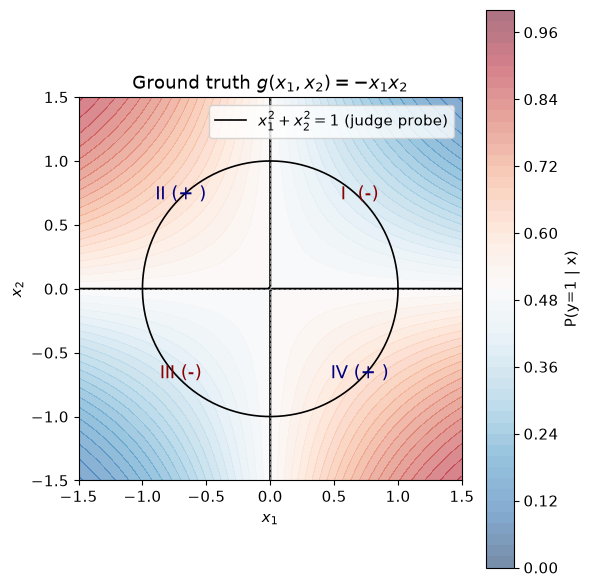

Blue = positive class (opposite signs). Red = negative (same signs).


In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

prob_grid = model_prob(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

im = ax.contourf(XX, YY, prob_grid, levels=np.linspace(0, 1, 51),
                 cmap='RdBu_r', alpha=0.55)
ax.contour(XX, YY, prob_grid, levels=[0.5], colors='k', linewidths=1.5)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.axvline(0, color='gray', lw=0.7, ls='--')

for xx_, yy_, s, c in [(0.7, 0.7, 'I  (-)', 'darkred'),
                        (-0.7, 0.7, 'II (+ )', 'navy'),
                        (-0.7, -0.7, 'III (-)', 'darkred'),
                        (0.7, -0.7, 'IV (+ )', 'navy')]:
    ax.text(xx_, yy_, s, ha='center', color=c, fontsize=13)

theta_full = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta_full), np.sin(theta_full), color='k', lw=1.2,
        label=r'$x_1^2+x_2^2=1$ (judge probe)')

ax.set_xlim(-EXTENT, EXTENT)
ax.set_ylim(-EXTENT, EXTENT)
ax.set_aspect('equal')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'Ground truth $g(x_1,x_2) = -x_1 x_2$')
plt.colorbar(im, ax=ax, label='P(y=1 | x)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Blue = positive class (opposite signs). Red = negative (same signs).")

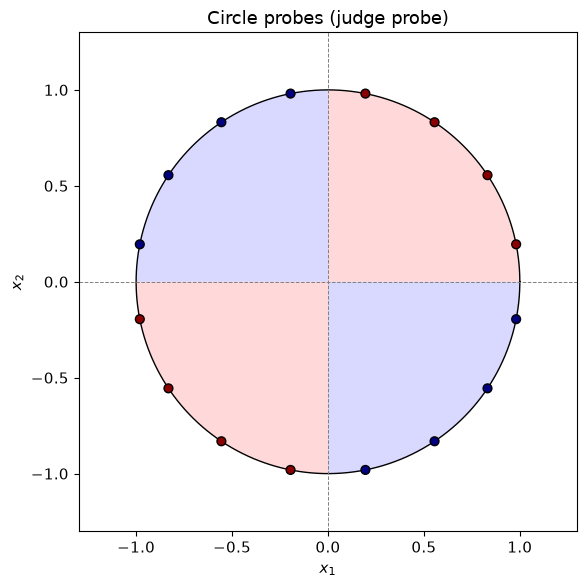

16 points, the judge probe. None lies on a coordinate axis, so the
interaction component is nonzero at every probe point.


In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

for a, b_, color in [(0, 90, 'red'), (90, 180, 'blue'),
                     (180, 270, 'red'), (270, 360, 'blue')]:
    ax.add_patch(Wedge((0, 0), 1.0, a, b_, facecolor=color, alpha=0.15))

theta_full = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta_full), np.sin(theta_full), color='k', lw=1.0)

cls = model_predict(X_circ)
colors = ['navy' if c else 'darkred' for c in cls]
ax.scatter(X_circ[:, 0], X_circ[:, 1], c=colors, s=40, edgecolors='k',
           zorder=5)

ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.axvline(0, color='gray', lw=0.7, ls='--')
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('Circle probes (judge probe)')
plt.tight_layout()
plt.show()

print("16 points, the judge probe. None lies on a coordinate axis, so the")
print("interaction component is nonzero at every probe point.")

## 3. The judge

Two modes.

### `mode='structural'` (L4)

The output has no component indexed by the pair {1,2}. A fact about the
output's format, independent of any probe.

    spec = {'mode': 'structural', 'reason': str}

### `mode='probe'` (L2 or L3)

The output carries a per-point value w_{1,2}(x). At each probe point the
judge compares the sign of that value with the sign of the rule constant
w_{1,2} = -1, which is negative. Zero values carry no sign and are excluded;
non-finite values are excluded as data errors.

- The sign opposes the rule sign at some probe point -> **L3**. A rule
  object carries the rule sign everywhere; a component that is positive at a
  probe point is not the rule.
- The sign agrees with the rule sign at every probe point -> **L2**. Only
  probe values are available; nothing is claimed about whether the output is
  a constant object.

    spec = {'mode': 'probe', 'fn': callable}

If no valid values are present on the probe (all zero or non-finite), the
judge returns **UD** (no verdict).

**L2 is a weak necessary condition, not a certificate:** outputs that are
negative on the whole probe (a negative constant, or -x_1^2 x_2^2) also
pass; and the outcome depends on the probe geometry. "L2 empty" is relative
to this probe.

### Not issued

- **L1** (rule object): the constant object w_{1,2} = -1 with lower-order
  coefficients zero. Requires external information: a function-class prior
  (knowing the basis x_1 x_2; in algorithmic form, a global symbolic search)
  or almost-everywhere coverage. See sections 7–8.

The rule constant is fixed by the design, so the judge is not subject to the
constraints that define the tested setting.

In [7]:
def judge_sxc(spec, X_probe=None):
    """
    SXC judge. Returns (level, reason).

    Verdicts issued:

      'L2'  probe      — the output's sign agrees with the rule sign at every
                         probe point carrying a valid (finite, nonzero) value.
                         Rule constant w_{1,2} = -1, so the rule sign is
                         negative. Only probe values are available, so nothing
                         is claimed about whether the output is a constant
                         object. L2 is a weak necessary condition, not a
                         certificate; the outcome can depend on the probe.
      'L3'  probe      — the output's sign opposes the rule sign at some
                         probe point. A rule object carries the rule sign
                         everywhere, so such an output is not the rule.
      'L4'  structural — no component is indexed by {1,2}.
      'UD'  probe      — no valid values on the probe: nothing to compare;
                         no verdict.

    Zero values carry no sign and are excluded (and reported); non-finite
    values are data errors and are excluded (and reported). If nothing valid
    remains, the result is 'UD'.

    L1 (the rule object itself) is the target of the experiment, not a
    verdict. The rule constant is fixed by the design, so the judge is not
    subject to the constraints that define the tested setting.
    """
    mode = spec.get('mode')

    if mode == 'structural':
        return 'L4', f"[structure] {spec['reason']}"

    if mode == 'probe':
        X = np.atleast_2d(np.asarray(X_probe, dtype=float))
        vals = np.asarray(spec['fn'](X), dtype=float)

        finite = np.isfinite(vals)
        n_bad = int((~finite).sum())
        n_zero = int((finite & (vals == 0.0)).sum())
        nonzero = finite & (vals != 0.0)
        n_valid = int(nonzero.sum())

        if n_valid == 0:
            return 'UD', (
                f"[probe] no valid values: {n_zero} zero, {n_bad} non-finite "
                f"point(s). Nothing to compare against the rule sign; "
                f"no verdict."
            )

        n_rule = int((vals[nonzero] < 0.0).sum())
        n_opp = n_valid - n_rule
        excl = ("" if n_zero + n_bad == 0 else
                f" ({n_zero} zero, {n_bad} non-finite point(s) excluded; "
                f"zeros carry no sign)")

        if n_opp > 0:
            return 'L3', (
                f"[probe] the output's sign opposes the rule sign at "
                f"{n_opp}/{n_valid} probe points with valid values "
                f"(carries it at {n_rule}/{n_valid}){excl}. Rule constant "
                f"w_{{1,2}} = -1: negative. A rule object carries the rule "
                f"sign everywhere, so the output is not the rule."
            )

        return 'L2', (
            f"[probe] the output's sign agrees with the rule sign at every "
            f"probe point with valid values ({n_rule}/{n_valid}){excl}. Only "
            f"probe values are available; nothing is claimed about whether "
            f"the output is a constant object."
        )

    raise ValueError(f"Unknown mode: {mode}")

## 4. Interaction components: contribution = coefficient * basis

Harsanyi dividend, AOG and SHAP-IQ all report, at each point, the **contribution** of the pair {1,2}:

    contribution(x) = coefficient * basis(x) = (-1) * x_1 x_2

The rule, in separated form, is the two factors written side by side (the
coefficient together with its basis), not a single number the method
prints. The **contribution** is a function of x. The methods return a value
at each queried point; no method returns a closed form; the identification
of the values with (-1) * x_1 * x_2 is an observation we make about them,
and even that form is not the rule: the rule is the two factors kept apart,
and the split is not in the data. At (1,1) the delivered value is a single
number, -1; (-1) * (x_1^n x_2^n) reproduces it for every real n (1^n = 1).
n = 1 gives the quadrant rule; n = 2 has basis x_1^2 x_2^2 and is a
different rule (negative everywhere off the axes). Only pinning a basis (a
prior) makes the split unique.

Its sign therefore flips with the basis:

    quadrants I, III : x_1 x_2 > 0  ->  contribution < 0  (same sign as -1)
    quadrants II, IV : x_1 x_2 < 0  ->  contribution > 0  (opposite to -1)

The probe records this split. Neither set is a "score": the split is the
signature that the component does not carry the rule sign as a constant.

In [8]:
Q_NODES = np.array([[a, c] for a in (-2.0, -1.0, 1.0, 2.0)
                            for c in (-2.0, -1.0, 1.0, 2.0)])

def make_game(x, baseline=None):
    """
    Cooperative game v(S) for one point x, built from black-box queries to
    model_logit. The target's formula does not appear here, and no value is
    written down from knowledge of the target.

    baseline array : interventional, v(S) = g(x_S, baseline_{S^c})
    baseline None  : distributional on the finite symmetric background
                     Q_NODES, v(S) = mean_{z in Q_NODES} g(x_S, z_{S^c})
    """
    x = np.asarray(x, dtype=float)

    def game(coalition_matrix):
        C = np.asarray(coalition_matrix, dtype=bool)
        if baseline is not None:
            ref = np.asarray(baseline, dtype=float)
            Z = np.tile(ref, (len(C), 1))
            Z[:, 0] = np.where(C[:, 0], x[0], ref[0])
            Z[:, 1] = np.where(C[:, 1], x[1], ref[1])
            return model_logit(Z)
        acc = np.zeros(len(C))
        for z in Q_NODES:
            Z = np.tile(z, (len(C), 1))
            Z[:, 0] = np.where(C[:, 0], x[0], z[0])
            Z[:, 1] = np.where(C[:, 1], x[1], z[1])
            acc += model_logit(Z)
        return acc / len(Q_NODES)

    return game

def shapiq_values(x, index, baseline=None):
    """
    All interaction values of the game at x, computed exactly by shapiq
    (ExactComputer enumerates all 2^n coalitions; no sampling).
    Returns a dict: coalition -> value at this x.
    """
    computer = shapiq.ExactComputer(game=make_game(x, baseline), n_players=2)
    iv = computer(index)
    parts = getattr(iv, "dict_values", None)
    if parts is None:  # fallback for API differences across shapiq versions
        parts = {tuple(k): iv.values[i] for k, i in iv.interaction_lookup.items()}
    return {tuple(k): float(v) for k, v in parts.items()}

def shapiq_component(index, baseline=None):
    """The pair value w_{1,2}(x) as a callable, for the judge."""
    def fn(X):
        X = np.atleast_2d(X)
        return np.array([shapiq_values(x, index, baseline)[(0, 1)] for x in X])
    return fn

B0 = np.array([0.0, 0.0])
B5 = np.array([0.5, 0.5])

# --- the full decomposition at one probe point ------------------------------
x_show = X_circ[0]
parts = shapiq_values(x_show, "Moebius", B0)
print("Moebius (Harsanyi) terms at x =", np.round(x_show, 4), "with b = (0, 0):")
for key in [(), (0,), (1,), (0, 1)]:
    if key in parts:
        label = "(empty)" if key == () else str(key)
        print(f"  delta_{label}: {parts[key]:+.6f}")
print(f"  g(x) = {model_logit(x_show)[0]:+.6f}")

# --- exactness, and the two indices at M = 2 --------------------------------
moe_b0 = shapiq_component("Moebius", B0)(X_circ)
sii_b0 = shapiq_component("SII", B0)(X_circ)
print()
print("max |SII pair - Moebius pair| on the probe:", np.abs(sii_b0 - moe_b0).max())
print("max |Moebius pair - g(x)| on the probe (b = 0):",
      np.abs(moe_b0 - model_logit(X_circ)).max())

# --- verdicts ---------------------------------------------------------------
# The symmetric node set has E[z_i] = 0 (independent coordinates), so the
# background game coincides with the b = 0 game for this target: the
# SII(bg) row equals SII(B0); the checks above use B0.
verdicts = {}
for name, index, baseline in [
    ("Harsanyi / Moebius (b = 0, 0)", "Moebius", B0),
    ("Harsanyi / Moebius (b = 0.5, 0.5)", "Moebius", B5),
    ("SHAP-IQ / SII (q symmetric)", "SII", None),
    ("SHAP-IQ / SII (b = 0.5, 0.5)", "SII", B5),
]:
    verdicts[name] = judge_sxc({"mode": "probe", "fn": shapiq_component(index, baseline)}, X_circ)
    lv, reason = verdicts[name]
    print()
    print(f"{name:<34s} -> {lv}")
    print(f"    {reason}")

print()
print("At b = 0 the pair term carries the whole logit: the empty, {1} and {2}")
print("terms vanish, and delta_{1,2}(x) = g(x) at every point evaluated. The")
print("attribution is exact. What is delivered is a value per point: no")
print("closed form, no constant -1. Turning values into the form (and with")
print("it the constant) requires a function-class prior, which this setting")
print("withholds (the split is not in the data).")

Moebius (Harsanyi) terms at x = [0.9808 0.1951] with b = (0, 0):
  delta_(empty): +0.000000
  delta_(0,): +0.000000
  delta_(1,): +0.000000
  delta_(0, 1): -0.191342
  g(x) = -0.191342

max |SII pair - Moebius pair| on the probe: 0.0
max |Moebius pair - g(x)| on the probe (b = 0): 0.0

Harsanyi / Moebius (b = 0, 0)      -> L3
    [probe] the output's sign opposes the rule sign at 8/16 probe points with valid values (carries it at 8/16). Rule constant w_{1,2} = -1: negative. A rule object carries the rule sign everywhere, so the output is not the rule.

Harsanyi / Moebius (b = 0.5, 0.5)  -> L3
    [probe] the output's sign opposes the rule sign at 8/16 probe points with valid values (carries it at 8/16). Rule constant w_{1,2} = -1: negative. A rule object carries the rule sign everywhere, so the output is not the rule.

SHAP-IQ / SII (q symmetric)        -> L3
    [probe] the output's sign opposes the rule sign at 8/16 probe points with valid values (carries it at 8/16). Rule constant w

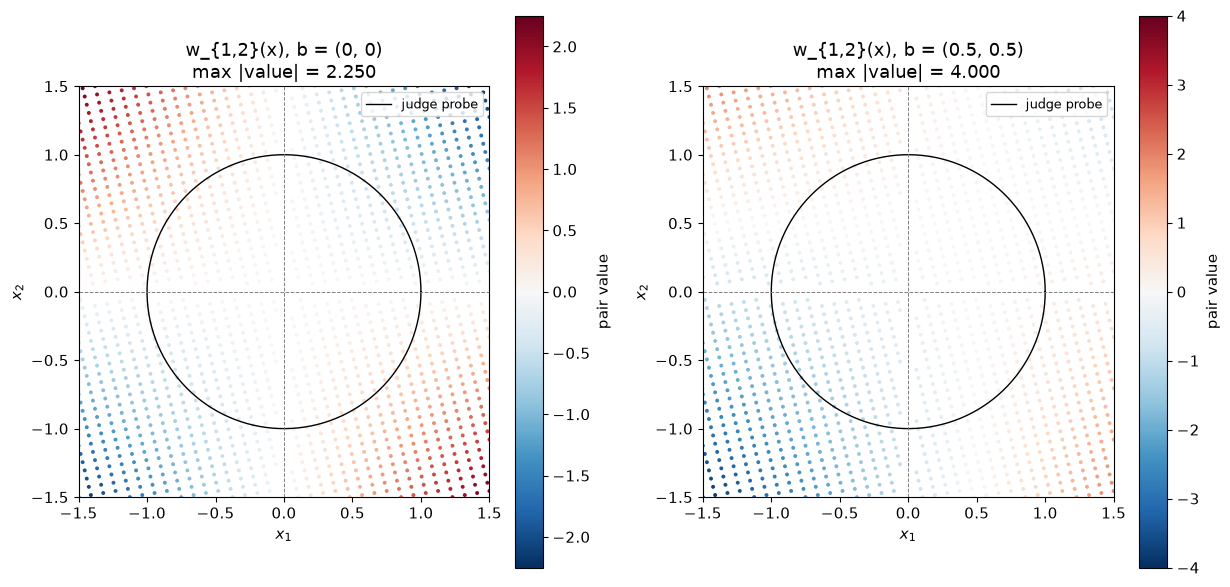

Values: shapiq ExactComputer, index Moebius, one call per point.
Each panel has its own color scale, so patterns are comparable across
panels, magnitudes are not. The additive methods have no pair
coordinate to plot here: that is their L4 verdict.


In [9]:
# Pair values over the plane, computed by shapiq on a subsample of the grid.
# Each panel keeps its own color scale: the panels differ by the reference
# point, so their value ranges differ.
X_plot = X_grid[::25]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 6))

for ax, baseline, title in zip(
        axes,
        (np.array([0.0, 0.0]), np.array([0.5, 0.5])),
        ("b = (0, 0)", "b = (0.5, 0.5)")):
    vals = shapiq_component("Moebius", baseline)(X_plot)
    vmax = np.abs(vals).max()

    sc = ax.scatter(X_plot[:, 0], X_plot[:, 1], c=vals, cmap='RdBu_r',
                    vmin=-vmax, vmax=vmax, s=8, linewidths=0)

    theta_full = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(theta_full), np.sin(theta_full), color='k', lw=1.0,
            label='judge probe')
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')
    ax.set_xlim(-EXTENT, EXTENT)
    ax.set_ylim(-EXTENT, EXTENT)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_title(f'w_{{1,2}}(x), {title}\nmax |value| = {vmax:.3f}')
    ax.legend(loc='upper right', fontsize=9)
    plt.colorbar(sc, ax=ax, label='pair value')

plt.tight_layout()
plt.show()

print("Values: shapiq ExactComputer, index Moebius, one call per point.")
print("Each panel has its own color scale, so patterns are comparable across")
print("panels, magnitudes are not. The additive methods have no pair")
print("coordinate to plot here: that is their L4 verdict.")

In [10]:
# Requires a clone of https://github.com/sjtu-xai-lab/aog; set AOG_SRC to its
# src folder. Importing the package sets matplotlib's backend to Agg, so run
# this cell after the plotting cells.
import sys

AOG_SRC = "./src" # clone of <github.com/sjtu-xai-lab/aog> commit bd17fb9
if AOG_SRC not in sys.path:
    sys.path.insert(0, AOG_SRC)

from harsanyi import AndHarsanyi

def aog_pair(x, baseline):
    """Pair value w_{1,2}(x) from the official AndHarsanyi implementation."""
    calc = AndHarsanyi(
        model=torch_model,
        selected_dim="logistic-odds",
        x=torch.tensor([[float(x[0]), float(x[1])]]),
        baseline=torch.tensor([[float(baseline[0]), float(baseline[1])]]),
        y=None,
        all_players=None,
        mask_input_fn=None,
        verbose=0,
    )
    calc.attribute()
    Iand = calc.get_interaction().detach().cpu().numpy()
    masks = [list(map(bool, m)) for m in calc.get_masks().tolist()]
    return float(Iand[masks.index([True, True])])

def aog_component(baseline):
    def fn(X):
        X = np.atleast_2d(X)
        return np.array([aog_pair(x, baseline) for x in X])
    return fn

for name, baseline in [("AOG / AndHarsanyi (b = 0, 0)", B0),
                       ("AOG / AndHarsanyi (b = 0.5, 0.5)", B5)]:
    verdicts[name] = judge_sxc({"mode": "probe", "fn": aog_component(baseline)}, X_circ)
    lv, reason = verdicts[name]
    print(f"{name:<34s} -> {lv}")
    print(f"    {reason}")

print()
print("max |AOG - shapiq Moebius| on the probe (b = 0):",
      f"{np.abs(aog_component(B0)(X_circ) - shapiq_component('Moebius', B0)(X_circ)).max():.2e}")

AOG / AndHarsanyi (b = 0, 0)       -> L3
    [probe] the output's sign opposes the rule sign at 8/16 probe points with valid values (carries it at 8/16). Rule constant w_{1,2} = -1: negative. A rule object carries the rule sign everywhere, so the output is not the rule.
AOG / AndHarsanyi (b = 0.5, 0.5)   -> L3
    [probe] the output's sign opposes the rule sign at 8/16 probe points with valid values (carries it at 8/16). Rule constant w_{1,2} = -1: negative. A rule object carries the rule sign everywhere, so the output is not the rule.

max |AOG - shapiq Moebius| on the probe (b = 0): 1.42e-08


In [11]:
x_demo = X_circ[0]

# --- additive SHAP (shap) ---------------------------------------------------
background = np.zeros((1, 2))                  # reference point b = 0
shap_explainer = shap.KernelExplainer(model_logit, background)
# nsamples=4: a two-feature game has four coalitions; the explainer solves
# on the full set (no sampling noise).
sv = shap_explainer.shap_values(x_demo.reshape(1, 2), nsamples=4)
print("shap (additive), one probe point")
print("  phi          :", sv[0])
print("  sum(phi)     :", sv[0].sum())
print("  f(x) - E[f]  :", model_logit(x_demo)[0] - float(shap_explainer.expected_value))
print("  phi_1 == g(x)/2 exactly:", bool(np.isclose(sv[0][0], model_logit(x_demo)[0] / 2)))
print("  no coordinate exists for the pair {1,2}")

# --- LIME -------------------------------------------------------------------
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array([[-1., -1.], [-1., 1.], [1., -1.], [1., 1.],
                            [0.5, 0.5], [-0.5, 0.5], [0.5, -0.5], [-0.5, -0.5]]),
    mode="regression",
    feature_names=["x1", "x2"],
    discretize_continuous=False,
)
lime_exp = lime_explainer.explain_instance(x_demo, model_logit, num_features=2)
print()
print("lime, one probe point")
print("  coefficients :", lime_exp.as_list())

# --- Integrated Gradients (captum) ------------------------------------------
# captum's IG needs input gradients (internal access), which the black-box
# setting excludes; it is kept here as an additive baseline.
ig = IntegratedGradients(torch_model)
ig_attr = ig.attribute(torch.tensor([[float(x_demo[0]), float(x_demo[1])]]),
                       baselines=torch.zeros(1, 2), n_steps=64)
print()
print("captum IntegratedGradients, one probe point")
print("  attributions :", ig_attr.detach().numpy()[0])
print()

verdicts["SHAP (additive)"] = judge_sxc({"mode": "structural", "reason":
    "shap.KernelExplainer returns a per-feature attribution vector "
    "(phi_1, phi_2); no component is indexed by the pair {1,2} (the "
    "interaction is smeared into the two main effects)"})
verdicts["LIME"] = judge_sxc({"mode": "structural", "reason":
    "lime returns a per-sample local linear coefficient vector; additive, "
    "no component is indexed by the pair {1,2}"})
verdicts["IntegratedGradients"] = judge_sxc({"mode": "structural", "reason":
    "captum returns a per-feature attribution vector (IG_1, IG_2); no "
    "component is indexed by the pair {1,2}"})
verdicts["Counterfactual"] = judge_sxc({"mode": "structural", "reason":
    "output is a per-sample boundary point and offset vector (Wachter et "
    "al. 2017); no component is indexed by the pair {1,2}"})

for name in ("SHAP (additive)", "LIME", "IntegratedGradients", "Counterfactual"):
    lv, reason = verdicts[name]
    print(f"{name:<28s} -> {lv}")
    print(f"    {reason}")

print()
print("At b = 0 the additive values carry the logit through the two main")
print("  effects; the exact additive Shapley values split it evenly:")
print("  phi_1 = phi_2 = -x_1 x_2 / 2, and phi_1 + phi_2 = g(x).")
print("  There is no third coordinate for {1,2}: the interaction is smeared")
print("  into the two main effects. That is the L4 verdict: a fact about the")
print("  output format, independent of any probe.")

  0%|          | 0/1 [00:00<?, ?it/s]

shap (additive), one probe point
  phi          : [-0.09567086 -0.09567086]
  sum(phi)     : -0.19134171618254486
  f(x) - E[f]  : -0.19134171618254486
  phi_1 == g(x)/2 exactly: True
  no coordinate exists for the pair {1,2}

lime, one probe point
  coefficients : [('x2', -0.3433973507478382), ('x1', -0.05481402404744677)]

captum IntegratedGradients, one probe point
  attributions : [-0.09567085 -0.09567086]

SHAP (additive)              -> L4
    [structure] shap.KernelExplainer returns a per-feature attribution vector (phi_1, phi_2); no component is indexed by the pair {1,2} (the interaction is smeared into the two main effects)
LIME                         -> L4
    [structure] lime returns a per-sample local linear coefficient vector; additive, no component is indexed by the pair {1,2}
IntegratedGradients          -> L4
    [structure] captum returns a per-feature attribution vector (IG_1, IG_2); no component is indexed by the pair {1,2}
Counterfactual               -> L4
    [st

In [12]:
FAMILY = {
    'SHAP (additive)': 'additive attribution (shap)',
    'LIME': 'additive attribution (lime)',
    'IntegratedGradients': 'additive attribution (captum)',
    'Counterfactual': 'counterfactual',
    'Harsanyi / Moebius (b = 0, 0)': 'interaction decomposition (shapiq)',
    'Harsanyi / Moebius (b = 0.5, 0.5)': 'interaction decomposition (shapiq)',
    'AOG / AndHarsanyi (b = 0, 0)': 'interaction decomposition (official AOG)',
    'AOG / AndHarsanyi (b = 0.5, 0.5)': 'interaction decomposition (official AOG)',
    'SHAP-IQ / SII (q symmetric)': 'interaction decomposition (shapiq)',
    'SHAP-IQ / SII (b = 0.5, 0.5)': 'interaction decomposition (shapiq)',
}
OUTPUT = {
    'SHAP (additive)': 'per-sample (phi_1, phi_2), additive',
    'LIME': 'per-sample local linear coefficients',
    'IntegratedGradients': 'per-sample (IG_1, IG_2)',
    'Counterfactual': 'per-sample boundary point + offset',
    'Harsanyi / Moebius (b = 0, 0)': 'per-sample -x_1 x_2',
    'Harsanyi / Moebius (b = 0.5, 0.5)': 'per-sample -(x_1-.5)(x_2-.5)',
    'AOG / AndHarsanyi (b = 0, 0)': 'per-sample -x_1 x_2',
    'AOG / AndHarsanyi (b = 0.5, 0.5)': 'per-sample -(x_1-.5)(x_2-.5)',
    'SHAP-IQ / SII (q symmetric)': 'per-sample -x_1 x_2 (= Moebius pair term)',
    'SHAP-IQ / SII (b = 0.5, 0.5)': 'per-sample -(x_1-.5)(x_2-.5)',
}
ROW_ORDER = ['SHAP (additive)', 'LIME', 'IntegratedGradients', 'Counterfactual',
             'Harsanyi / Moebius (b = 0, 0)', 'Harsanyi / Moebius (b = 0.5, 0.5)',
             'AOG / AndHarsanyi (b = 0, 0)', 'AOG / AndHarsanyi (b = 0.5, 0.5)',
             'SHAP-IQ / SII (q symmetric)', 'SHAP-IQ / SII (b = 0.5, 0.5)']

rows = [{'family': FAMILY[n], 'method': n, 'output': OUTPUT[n],
         'verdict': verdicts[n][0]} for n in ROW_ORDER]
print(pd.DataFrame(rows).to_string(index=False))

print()
print("  L2 : probe witness. The output's sign agrees with the rule sign at")
print("       every probe point. Only probe values are available; nothing is")
print("       claimed about whether the output is a constant object.")
print("  L3 : probe witness. The output carries a per-point interaction")
print("       component whose sign opposes the rule sign at some probe point,")
print("       so the output is not the rule.")
print("  L4 : structural fact. No component of the output is indexed by")
print("       the pair {1,2}.")
print()
print("  L1 (rule object) is the target, not a verdict: reaching it requires")
print("  external information — a function-class prior (in algorithmic form, a")
print("  global symbolic search), or almost-everywhere coverage; see the")
print("  framework's sections 7–8.")
print()
print("  No method in the table reaches L2: every method with a {1,2}")
print("  component opposes the rule sign somewhere, and every method without")
print("  one is L4.")
print()
print("  The interaction rows are pointwise exact: at b = 0 the pair value")
print("  equals g(x) at every point evaluated. What they deliver is a value")
print("  per point, not a closed form; the form, and the rule, are not in the")
print("  output.")

                                  family                            method                                    output verdict
             additive attribution (shap)                   SHAP (additive)       per-sample (phi_1, phi_2), additive      L4
             additive attribution (lime)                              LIME      per-sample local linear coefficients      L4
           additive attribution (captum)               IntegratedGradients                   per-sample (IG_1, IG_2)      L4
                          counterfactual                    Counterfactual        per-sample boundary point + offset      L4
      interaction decomposition (shapiq)     Harsanyi / Moebius (b = 0, 0)                       per-sample -x_1 x_2      L3
      interaction decomposition (shapiq) Harsanyi / Moebius (b = 0.5, 0.5)              per-sample -(x_1-.5)(x_2-.5)      L3
interaction decomposition (official AOG)      AOG / AndHarsanyi (b = 0, 0)                       per-sample -x_1 x_2      L3
